# Análise Exploratória

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

DATA_PATH = '../data/'
file_name = 'telco_customer_churn_silver.csv'
df_eda = pd.read_csv(DATA_PATH+file_name, sep=',')
df_eda.head(1)

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [2]:
TARGET_COLUMN = 'Churn'
NUMERICAL_COLUMNS = ['Tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_COLUMNS = []

for column in df_eda.columns:
    if column not in NUMERICAL_COLUMNS and column != TARGET_COLUMN and column != 'CustomerID':
        CATEGORICAL_COLUMNS.append(column)

## Identificando proporção de Churn nos dados

### A distribuição da variável Churn é analisada para verificar a proporção de clientes que permaneceram (No) e que deixaram a empresa (Yes). Essa análise permite compreender a distribuição da variável-alvo e verificar se existe diferença significativa na quantidade de observações entre as classes.

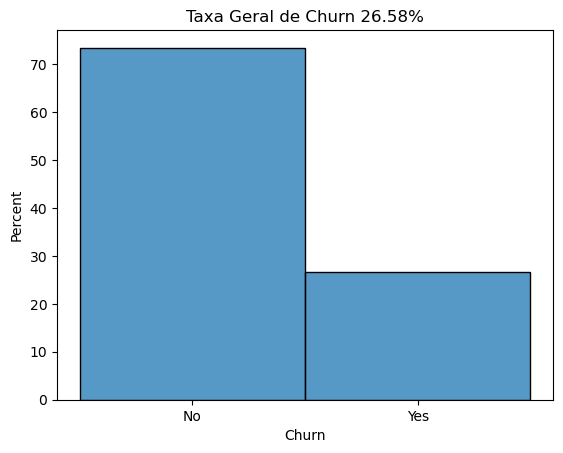

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

churn_count = df_eda[df_eda[TARGET_COLUMN] == 'Yes'].shape[0]
churn_rate = churn_count / df_eda.shape[0] * 100

fig, ax = plt.subplots()
ax.set_title(f'Taxa Geral de Churn {churn_rate:.2f}%')
sns.histplot(data=df_eda, x=TARGET_COLUMN, stat='percent')
plt.show()

### Verifica possíveis correlações, padrões, agrupamentos e valores discrepantes (outliers) entre as variáveis numéricas.

In [4]:
df_eda.describe()

,Tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


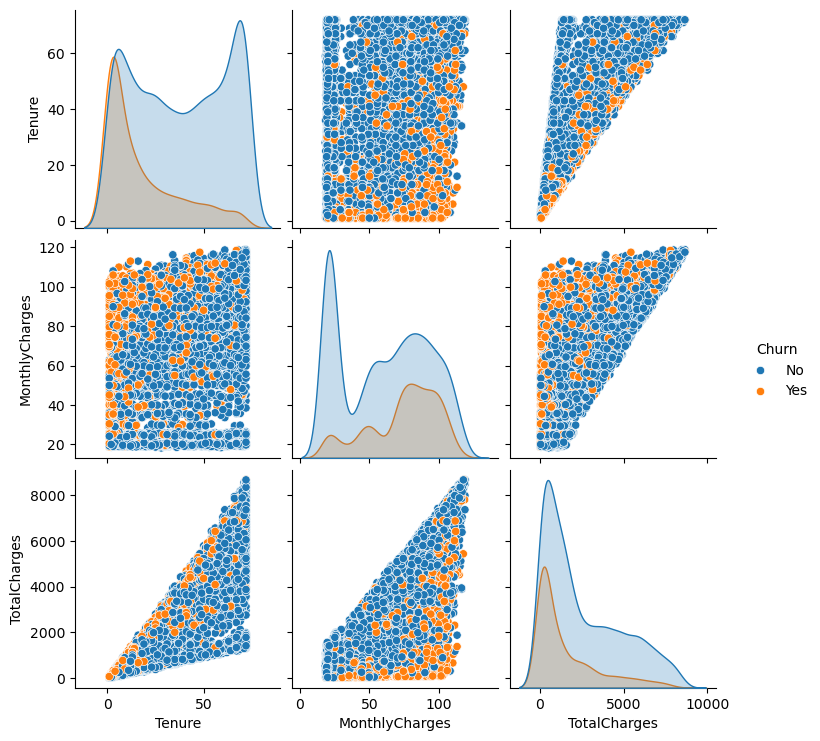

In [5]:
sns.pairplot(data=df_eda, hue=TARGET_COLUMN)

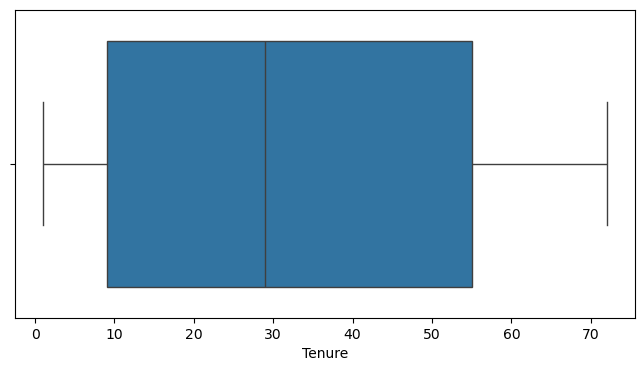

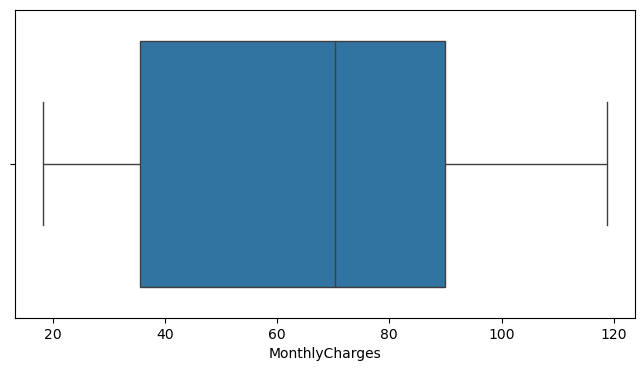

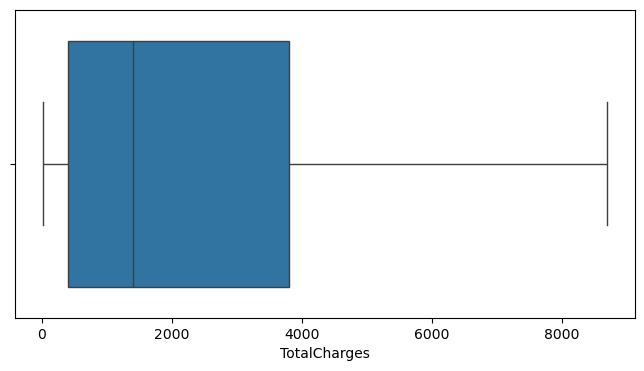

In [6]:
for column in NUMERICAL_COLUMNS:
    fig, ax = plt.subplots(figsize=(8,4))
    sns.boxplot(data=df_eda, x=column)
    plt.show()

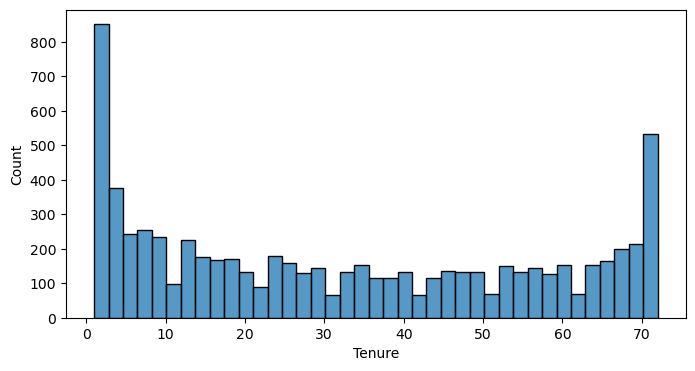

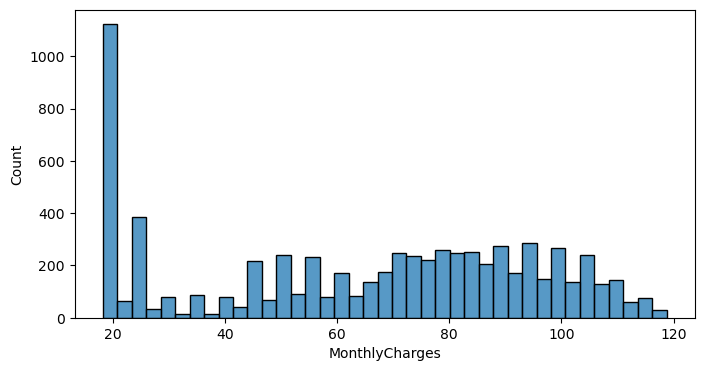

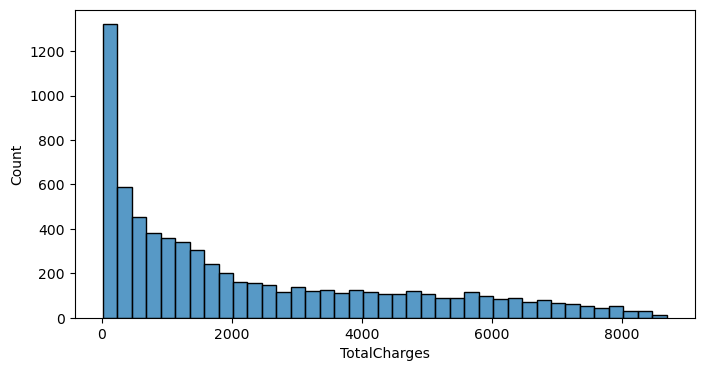

In [7]:
import math

for column in NUMERICAL_COLUMNS:
    fig, ax = plt.subplots(figsize=(8,4))

    # fórmula da regra de Rice para definir quantidade de classes
    k = math.ceil(2 * (df_eda.shape[0] ** (1/3)))
    sns.histplot(data=df_eda, x=column, bins=k)
    plt.show()

### Análise da frequência de churn entre as variáveis categóricas, buscando identificar quais grupos apresentam maior ou menor ocorrência de churn.

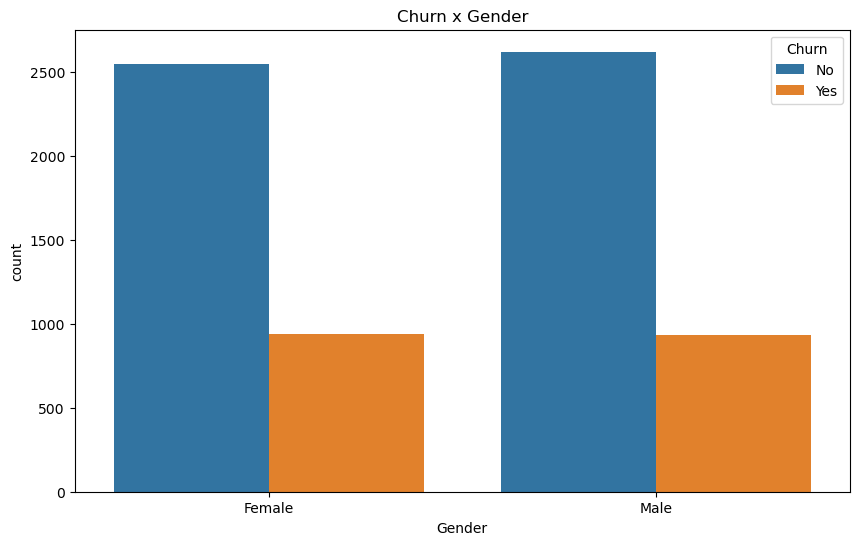

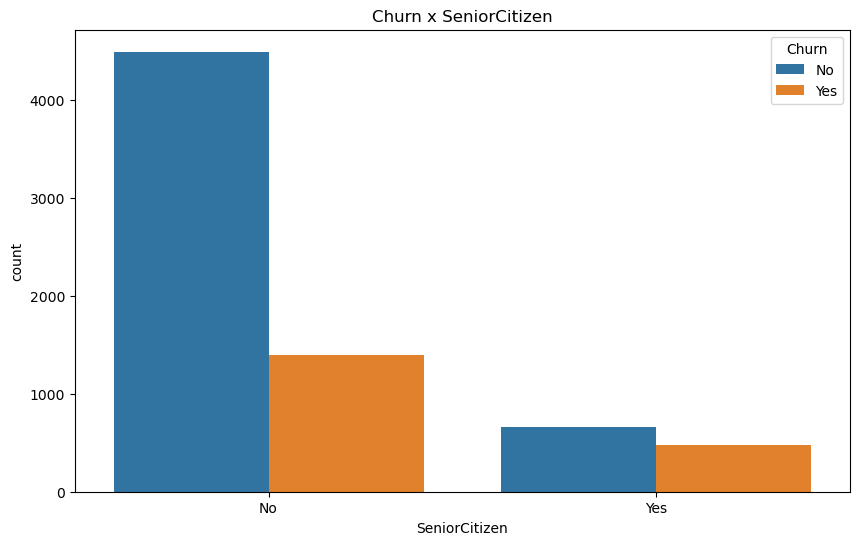

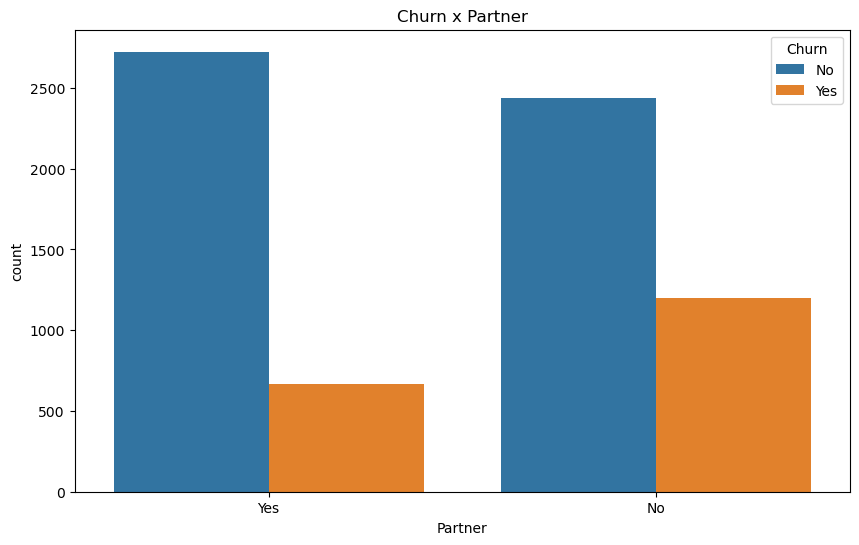

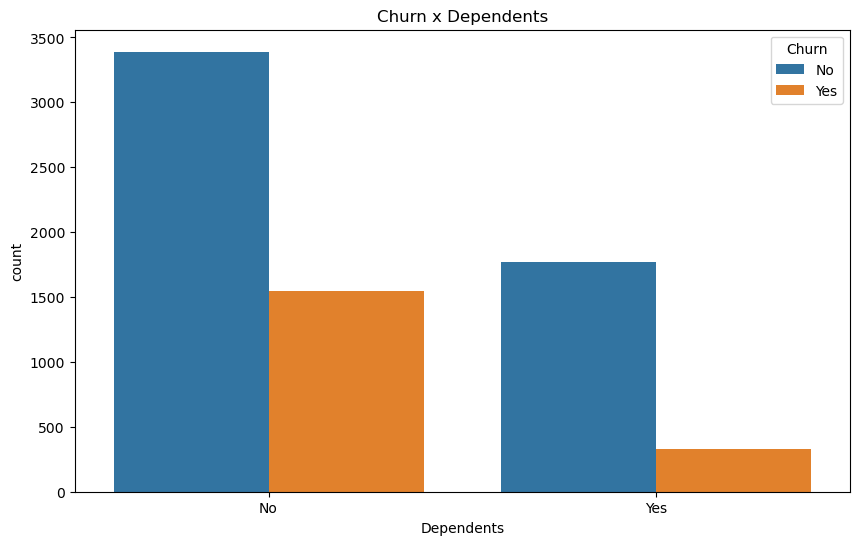

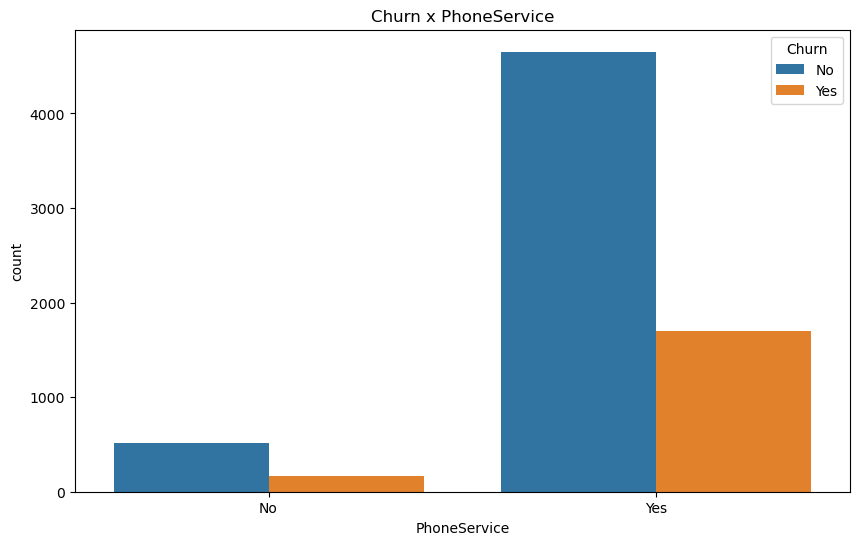

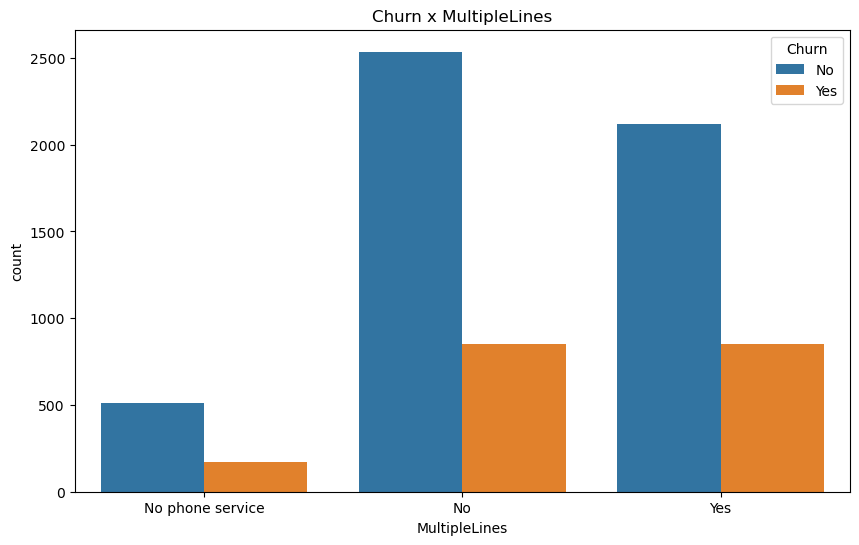

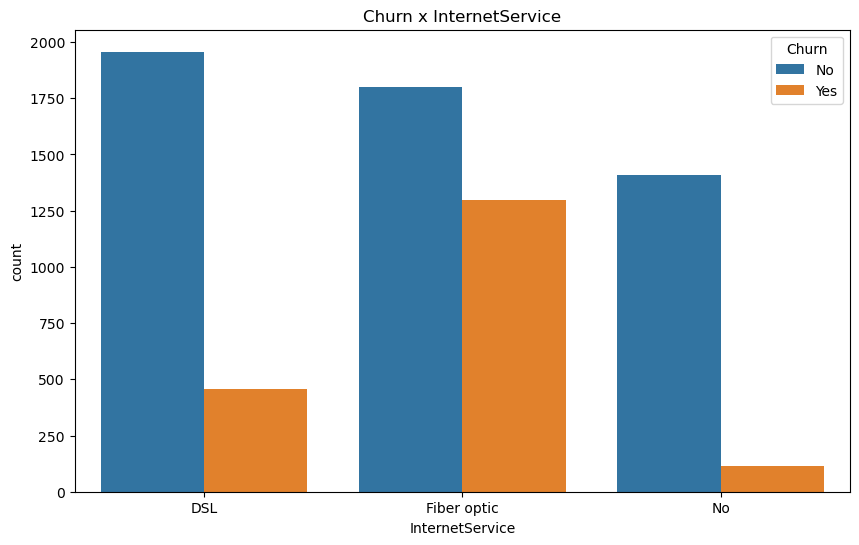

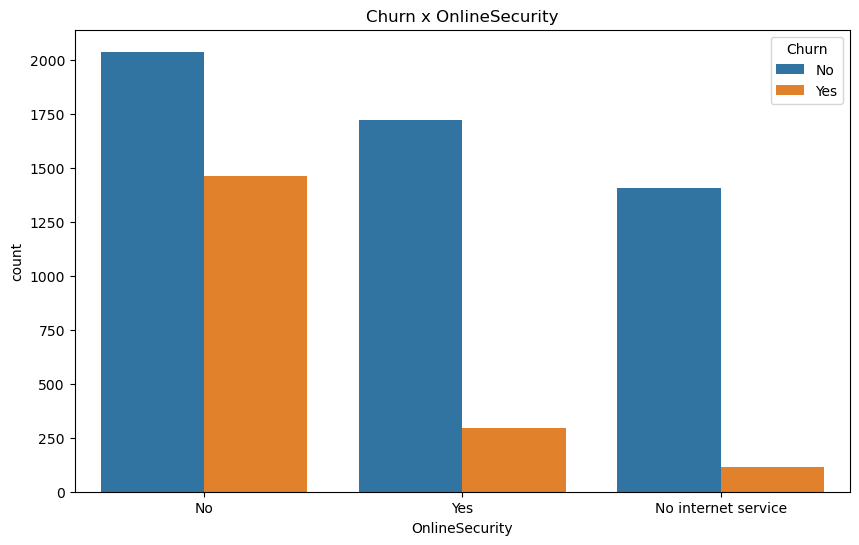

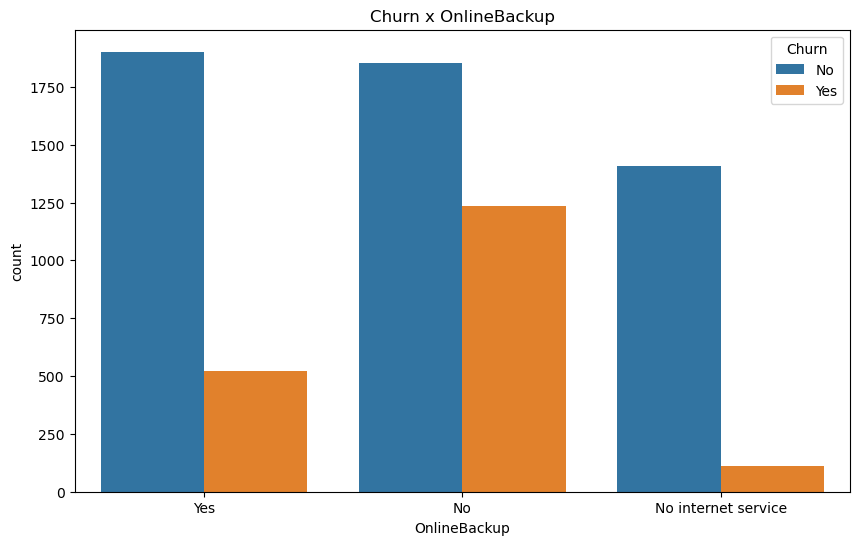

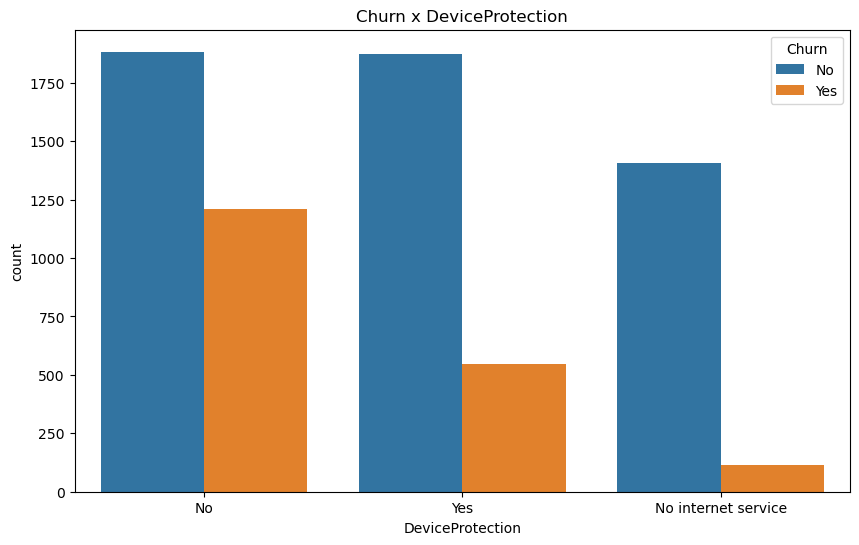

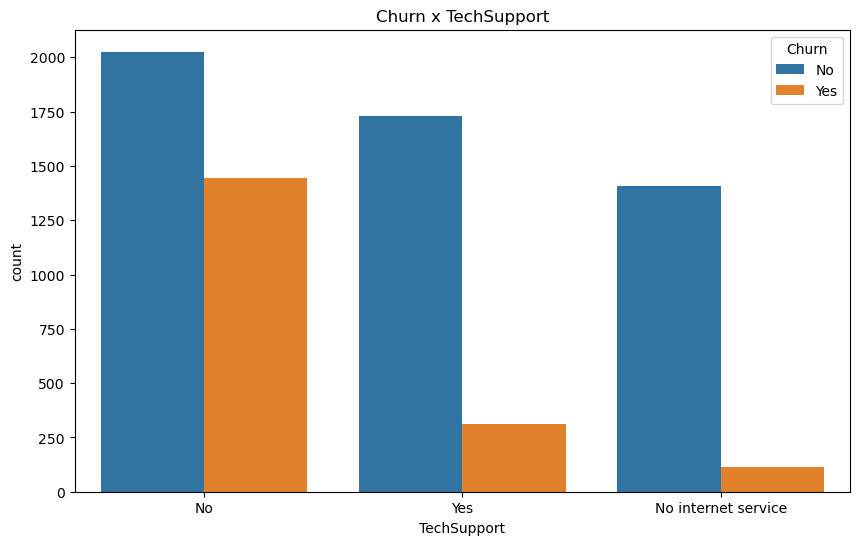

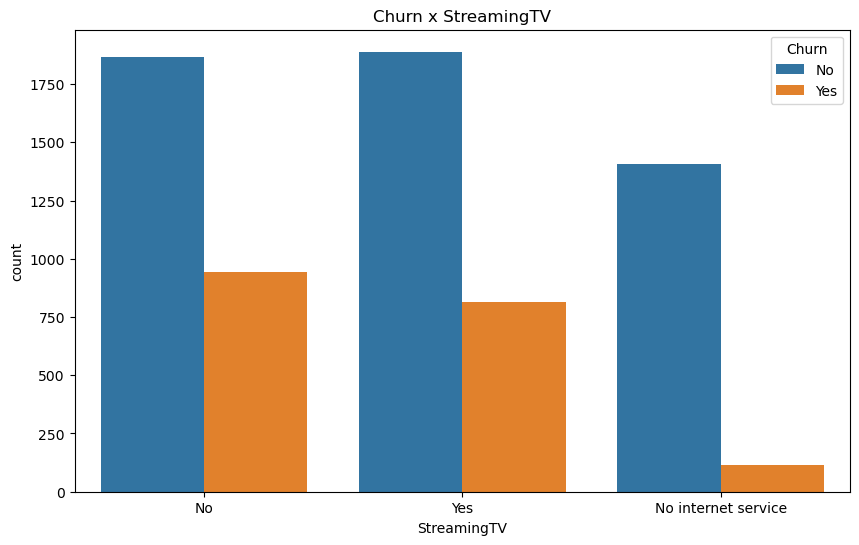

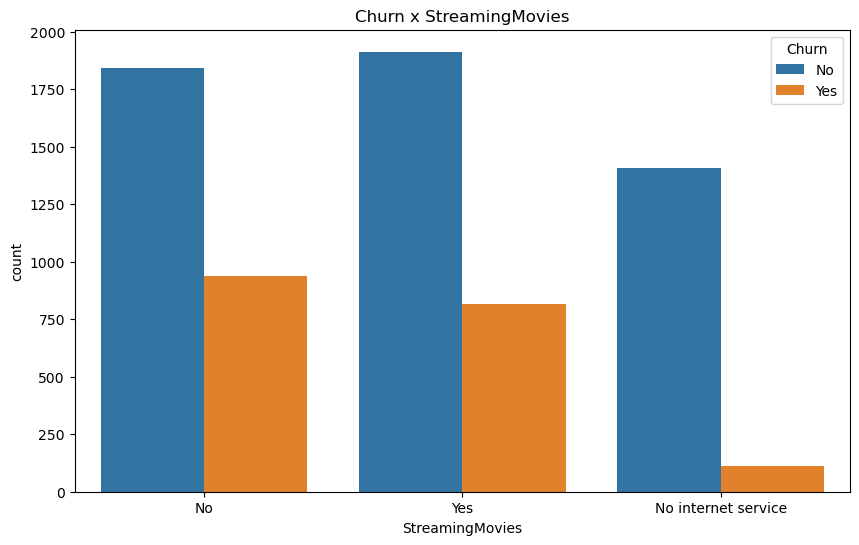

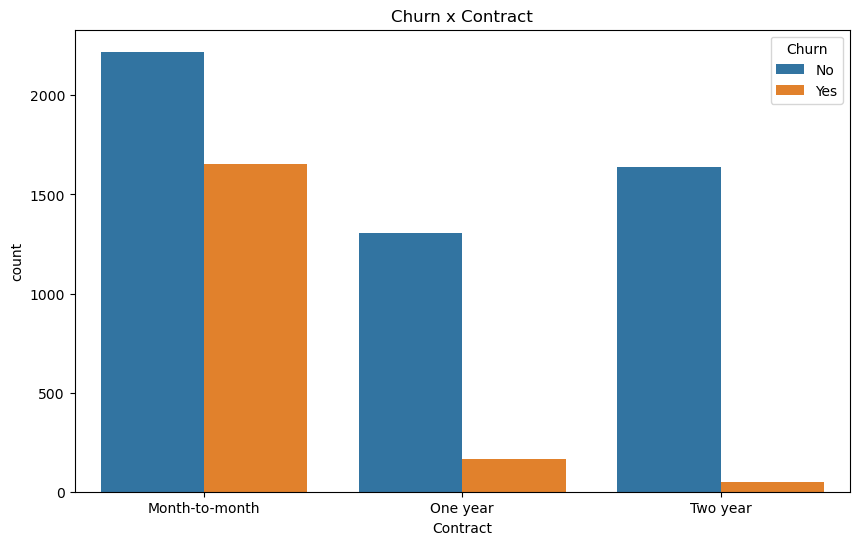

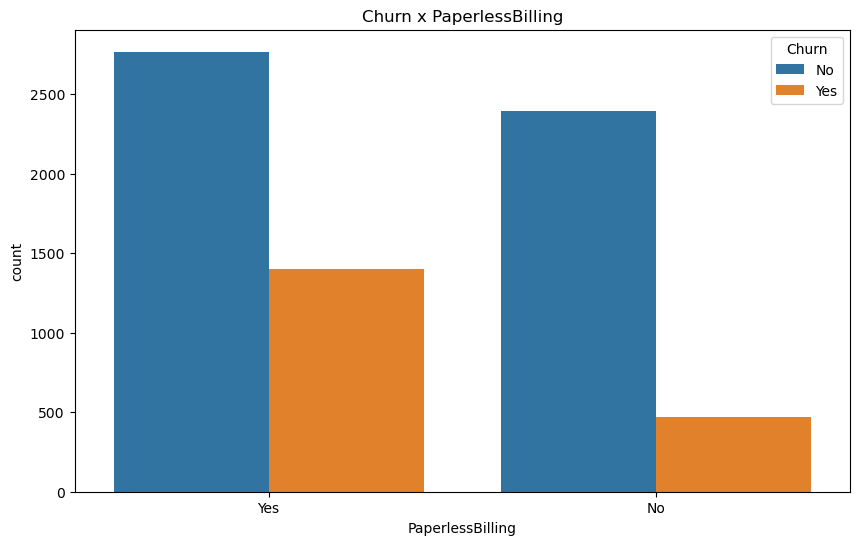

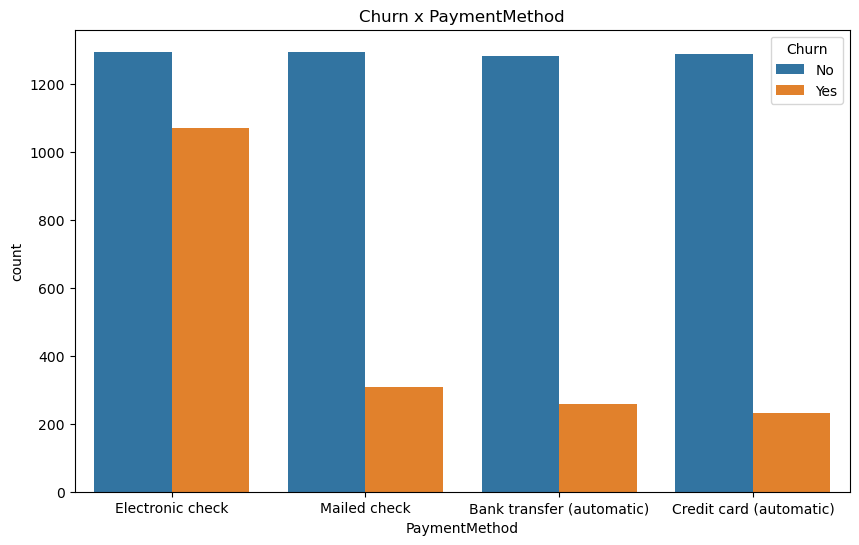

In [8]:
for column in CATEGORICAL_COLUMNS:
    fig, ax = plt.subplots(figsize=(10,6))
    
    sns.countplot(data=df_eda, x=column, hue=TARGET_COLUMN)
    
    ax.set_title(f'{TARGET_COLUMN} x {column}')
    ax.set_xlabel(column)
    plt.show()

## Identifica-se que, durante os 12 primeiros meses de contrato, o número de clientes que realizaram churn foi superior ao número de clientes que permaneceram na empresa.

<Axes: xlabel='Tenure', ylabel='Count'>

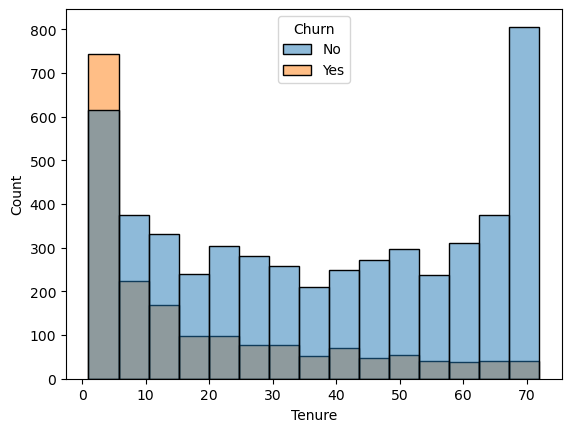

In [9]:
sns.histplot(data=df_eda, x='Tenure', hue=TARGET_COLUMN)

### Observa-se que 55,48% dos clientes que realizaram churn permaneceram na empresa por menos de 12 meses, indicando uma maior concentração de cancelamentos durante o primeiro ano de contrato.

In [10]:
df_tenure_churn = df_eda.copy()

# Cria uma nova coluna com os valores Yes e No para Tenure <= 12
df_tenure_churn['Tenure_under_12'] = df_tenure_churn['Tenure'].map(lambda x: 'Yes' if x <= 12 else 'No')

df_churn_yes = df_tenure_churn[df_tenure_churn['Churn'] == 'Yes']

tenure_under_12_count = df_churn_yes[df_churn_yes['Tenure_under_12'] == 'Yes'].shape[0]
churn_yes_count = df_churn_yes.shape[0]
print(f'O cancelamentos antes de 12 meses representam {tenure_under_12_count /  churn_yes_count * 100:.2f}%')

O cancelamentos antes de 12 meses representam 55.48%


<Axes: xlabel='Tenure_under_12', ylabel='count'>

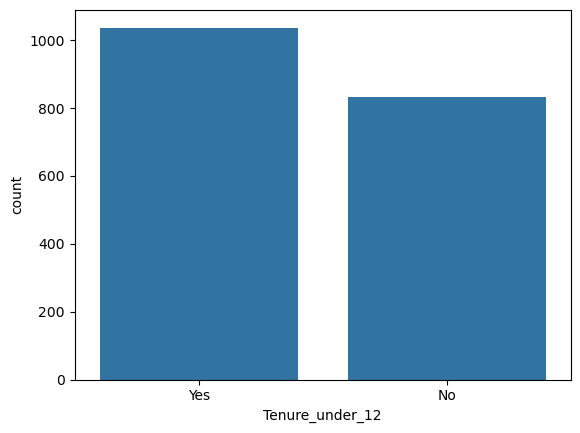

In [11]:
sns.countplot(data=df_churn_yes, x='Tenure_under_12')

In [12]:
top_churn_attributes = []

# IDENTIFICA OS ATRIBUTOS COM MAIOR CHURN DE CADA COLUNA CATEGORICA
for column in CATEGORICAL_COLUMNS:
    index_name = column
    column_value = ''
    max_count = 0
    
    for i in range(len(df_churn_yes[column].unique())):
        # pega o valor retornado pelo 'count' na posição i
        count = df_churn_yes.groupby([column]).count()['Churn'].iloc[i]
        
        if count > max_count:
            # pega o atributo da coluna retornado pelo na posição i
            column_value = df_churn_yes.groupby([column]).count()['Churn'].index[i]   
            # caso valor obtido em 'count' seja maior que 'max_count' atribui o valor ao 'max_count'
            max_count = df_churn_yes.groupby([column]).count()['Churn'].iloc[i]
            
    # adiciona em 'top_churn_attributes' uma lista [coluna, atributo, contagem], somente do atributo que obteve o maior 'count'
    top_churn_attributes.append([index_name, column_value, max_count]) 

### Identificação das variáveis categóricas e respectivas categorias que apresentam as maiores taxas de churn, permitindo destacar os grupos com maior concentração de clientes que deixaram o serviço.

<Axes: xlabel='Count', ylabel='Description'>

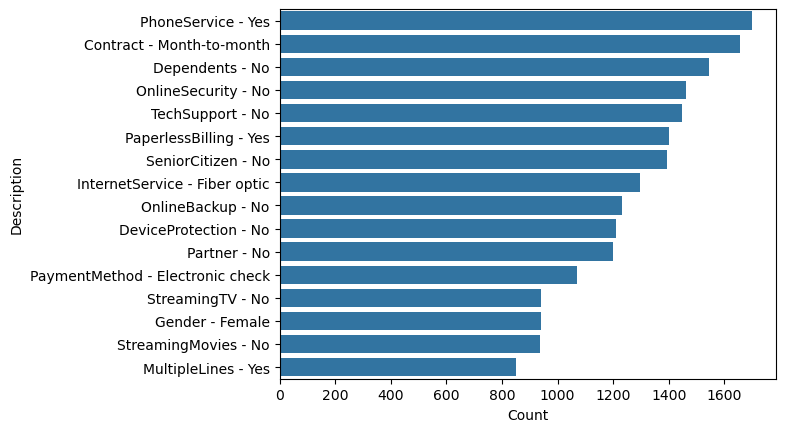

In [13]:
df_top_churn = pd.DataFrame(top_churn_attributes)
df_top_churn = df_top_churn.rename(columns={0:'Column', 1:'Attribute', 2:'Count'})

# cria uma coluna 'Description' que descreve a variável e o atributo dela
df_top_churn['Description'] = df_top_churn['Column'] + ' - ' + df_top_churn['Attribute']

df_top_churn = df_top_churn.drop(['Column', 'Attribute'], axis=1)
df_top_churn = df_top_churn.sort_values('Count', ascending=False)

sns.barplot(data=df_top_churn, x='Count', y='Description')

# Testes de hipóteses

In [14]:
import numpy as np
from scipy.stats import chi2_contingency

# FUNÇÃO QUI-QUADRADO
def fn_chi2_test(column):
    # Criando a tabela de contingência (cruzamento das variáveis)
    contingency_table = pd.crosstab(df_eda[TARGET_COLUMN], df_eda[column])
    
    # Executando o Teste Qui-Quadrado
    chi2, p_valor, dof, expected = chi2_contingency(contingency_table)
    
    print(f"chi2: {chi2:.4f}")
    print(f"p-valor: {p_valor:.4f}")
    
    # Interpretação do p-valor
    if p_valor < 0.05:
        print(f'Resultado: Existe uma associação estatisticamente significativa entre {TARGET_COLUMN} e {column}.')
    else:
        print(f'Resultado: Não Existe uma associação estatisticamente significativa entre {TARGET_COLUMN} e {column}.')
    
    # Calculando o V de Cramer (Força da associação, 0 nenhuma associação, 1 associação perfeita)
    n = contingency_table.sum().sum() # Total de observações
    min_dim = min(contingency_table.shape) - 1 # Menor dimensão da tabela menos 1
    v_cramer = np.sqrt(chi2 / (n * min_dim)) # calcula V de Cramer
    
    print(f"V de Cramer (Força da relação): {v_cramer:.4f} \n")

    # Calcula os Resíduos Padronizados
    #  Qualquer valor de resíduo maior que +2 ou menor que -2 indica um comportamento anormal e estatisticamente significante
    residuos = (contingency_table - expected) / np.sqrt(expected)
    display(residuos)

In [15]:
# CALCULO DA TAXA DE CHURN INTERNA
def fn_churn_rate(column):
    # O normalize='columns' divide os valores de cada célula pelo total daquela coluna
    churn_rate = pd.crosstab(df_eda[TARGET_COLUMN], df_eda[column], normalize='columns') * 100

    for valor in df_eda[column].unique():
        print(f"Taxa de Churn interna ({valor}): {churn_rate.loc['Yes', valor]:.2f}%")
    

## Churn x InternetService

### O teste de Qui-Quadrado confirmou uma associação significativa entre o tipo de internet e o Churn (p < 0.001). A análise de resíduos padronizados comprova que o serviço Fibra óptica tem forte impacto no cancelamento entre os clientes que possuem serviços de internet, apresentando uma taxa de Churn de 41,89%, valor estatisticamente muito superior ao comportamento do serviço DSL (19%) e de clientes sem internet (7,43%).

In [16]:
fn_chi2_test('InternetService')

chi2: 728.6956
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e InternetService.
V de Cramer (Força da relação): 0.3219 



InternetService,DSL,Fiber optic,No
Churn,,,
No,4.348254,-9.944548,8.710626
Yes,-7.227054,16.528425,-14.477574


In [17]:
fn_churn_rate('InternetService')

Taxa de Churn interna (DSL): 19.00%
Taxa de Churn interna (Fiber optic): 41.89%
Taxa de Churn interna (No): 7.43%


## Churn x OnlineSecurity

### O teste de Qui-Quadrado confirmou uma associação significativa entre o serviço de segurança online e o Churn (p < 0.001). A análise de resíduos padronizados comprova que clientes que não possuem o serviço apresentam uma taxa de Churn de 41,78%, estatisticamente muito superior ao comportamento de clientes que possuem (14,64%) e de clientes sem serviço de internet (7,43%).

In [18]:
fn_chi2_test('OnlineSecurity')

chi2: 846.6774
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e OnlineSecurity.
V de Cramer (Força da relação): 0.3470 



OnlineSecurity,No,No internet service,Yes
Churn,,,
No,-10.490220,8.710626,6.254151
Yes,17.435364,-14.477574,-10.394768


In [19]:
fn_churn_rate('OnlineSecurity')

Taxa de Churn interna (No): 41.78%
Taxa de Churn interna (Yes): 14.64%
Taxa de Churn interna (No internet service): 7.43%


## Churn x OnlineBackup

### O teste de Qui-Quadrado confirmou uma associação significativa entre o serviço de backup e o Churn (p < 0.001). A análise de resíduos padronizados comprova que clientes que não possuem o serviço apresentam uma taxa de Churn de (39,94%), superior ao comportamento de clientes que possuem (21,57%) e de clientes sem serviço de internet (7,43%).

In [20]:
fn_chi2_test('OnlineBackup')

chi2: 599.1752
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e OnlineBackup.
V de Cramer (Força da relação): 0.2919 



OnlineBackup,No,No internet service,Yes
Churn,,,
No,-8.664967,8.710626,2.880122
Yes,14.401686,-14.477574,-4.786933


In [21]:
fn_churn_rate('OnlineBackup')

Taxa de Churn interna (Yes): 21.57%
Taxa de Churn interna (No): 39.94%
Taxa de Churn interna (No internet service): 7.43%


## Churn x DeviceProtection

### O teste de Qui-Quadrado confirmou uma associação significativa entre o serviço de proteção de dispositivo e o Churn (p < 0.001). A análise de resíduos padronizados comprova que clientes que não possuem o serviço apresentam uma taxa de Churn de (39,14%), superior ao comportamento de clientes que possuem (22,54%) e de clientes sem serviço de internet (7,43%).

In [22]:
fn_chi2_test('DeviceProtection')

chi2: 555.8803
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e DeviceProtection.
V de Cramer (Força da relação): 0.2812 



DeviceProtection,No,No internet service,Yes
Churn,,,
No,-8.154540,8.710626,2.317997
Yes,13.553326,-14.477574,-3.852648


In [23]:
fn_churn_rate('DeviceProtection')

Taxa de Churn interna (No): 39.14%
Taxa de Churn interna (Yes): 22.54%
Taxa de Churn interna (No internet service): 7.43%


## Churn x Contract

### O teste de Qui-Quadrado confirmou uma associação significativa entre o tipo de contrato e o Churn (p < 0.001). A análise de resíduos padronizados comprova que clientes que possuem contrato month-to-month apresentam uma taxa de Churn de 42,71%, superior ao comportamento de clientes que possuem modelo One Year (11,28%) ou Two Year (2,85%).

In [24]:
fn_chi2_test('Contract')

chi2: 1179.5458
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e Contract.
V de Cramer (Força da relação): 0.4096 



Contract,Month-to-month,One year,Two year
Churn,,,
No,-11.718994,6.851273,11.367972
Yes,19.477659,-11.387220,-18.894240


In [25]:
fn_churn_rate('Contract')

Taxa de Churn interna (Month-to-month): 42.71%
Taxa de Churn interna (One year): 11.28%
Taxa de Churn interna (Two year): 2.85%


## Churn x PaymentMethod

### O teste de Qui-Quadrado confirmou uma associação significativa entre o método de pagamento e o Churn (p < 0.001). A análise de resíduos padronizados comprova que clientes que utilizam Cheque Eletrônico apresentam uma taxa de Churn de 45,29%, superior ao comportamento de clientes que utilizam o método Cheque físico (19,20%), Transferência bancária (16,73%) ou Cartão de crédito (15,25%)

In [26]:
fn_chi2_test('PaymentMethod')

chi2: 645.4299
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e PaymentMethod.
V de Cramer (Força da relação): 0.3030 



PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,4.512671,5.154726,-10.617104,3.447792
Yes,-7.500325,-8.567458,17.646253,-5.730434


In [27]:
fn_churn_rate('PaymentMethod')

Taxa de Churn interna (Electronic check): 45.29%
Taxa de Churn interna (Mailed check): 19.20%
Taxa de Churn interna (Bank transfer (automatic)): 16.73%
Taxa de Churn interna (Credit card (automatic)): 15.25%


# Correlação de todas as varáveis categoricas

In [28]:
# FUNÇÃO V-CRAMER
def fn_corr_v_cramer(column, column2):
    # Criando a tabela de contingência (cruzamento das variáveis)
    contingency_table = pd.crosstab(df_eda[column], df_eda[column2])
    
    # Executando o Teste Qui-Quadrado
    chi2, p_valor, dof, expected = chi2_contingency(contingency_table)
    
    # Calculando o V de Cramer (Força da associação, 0 nenhuma associação, 1 associação perfeita)
    n = contingency_table.sum().sum() # Total de observações
    min_dim = min(contingency_table.shape) - 1 # Menor dimensão da tabela menos 1
    v_cramer = np.sqrt(chi2 / (n * min_dim)) # calcula V de Cramer

    return v_cramer


In [29]:
categorical_corr = {}

corr_columns = CATEGORICAL_COLUMNS
corr_columns.append('Churn')
for column in sorted(CATEGORICAL_COLUMNS):
    column1 = column
    categorical_corr[column1] = {}

    for column in sorted(CATEGORICAL_COLUMNS, reverse=True):
        column2 = column

        v_cramer = fn_corr_v_cramer(column1, column2)

        categorical_corr[column1][column2] = v_cramer

df_corr_cat = pd.DataFrame(categorical_corr)
df_corr_cat.head()

,Churn,Contract,Dependents,DeviceProtection,Gender,InternetService,MultipleLines,OnlineBackup,OnlineSecurity,PaperlessBilling,Partner,PaymentMethod,PhoneService,SeniorCitizen,StreamingMovies,StreamingTV,TechSupport
TechSupport,0.342506,0.330575,0.180734,0.726461,0.008740,0.722809,0.229932,0.719807,0.733034,0.329113,0.127510,0.305974,0.176359,0.223709,0.716470,0.716248,1.000000
StreamingTV,0.230143,0.235329,0.145509,0.733526,0.007391,0.717195,0.261957,0.714687,0.707779,0.335901,0.136688,0.273046,0.180362,0.185417,0.771206,1.000000,0.716248
StreamingMovies,0.230702,0.238795,0.140044,0.736151,0.010121,0.715959,0.262437,0.713718,0.708224,0.331734,0.129910,0.273983,0.176948,0.188690,1.000000,0.771206,0.716470
SeniorCitizen,0.150105,0.143164,0.210129,0.182831,0.001434,0.264920,0.146730,0.182546,0.210728,0.155865,0.016571,0.195492,0.007739,0.999477,0.188690,0.185417,0.223709
PhoneService,0.011147,0.004848,0.000552,0.171894,0.007034,0.452255,1.000000,0.172421,0.175668,0.016206,0.017916,0.010549,0.999186,0.007739,0.176948,0.180362,0.176359


### Foi utilizado o V de Cramer para avaliar a associação entre as variáveis categóricas.Essa medida é adequada para dados categóricos e permite identificar a força da correlação entre si.Os valores variam de 0 a 1, 0 representa nenhuma associação e 1 representa associação perfeita.

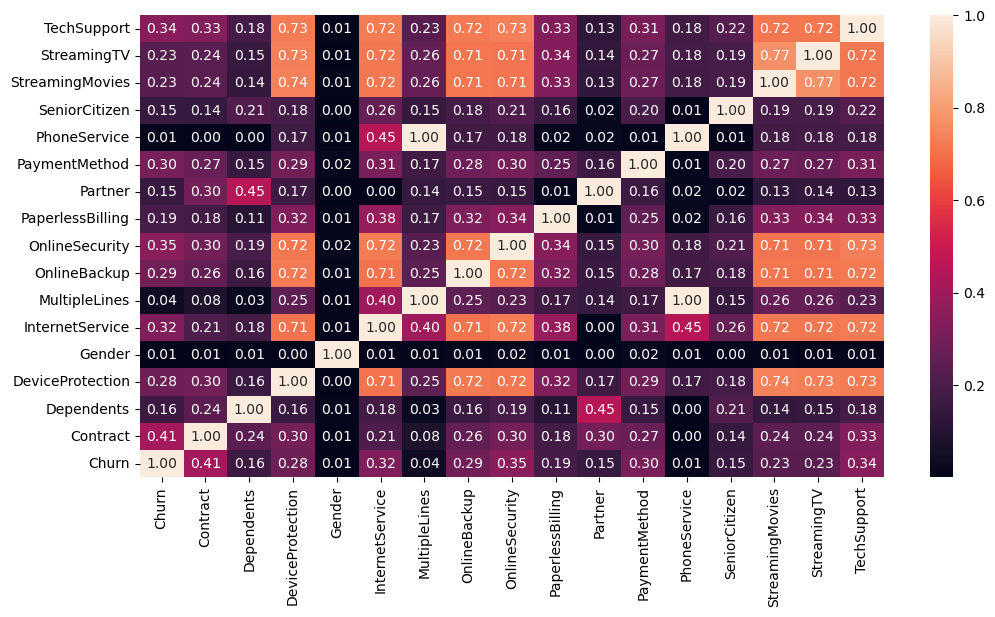

In [30]:
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df_corr_cat, annot=True, fmt=".2f", ax=ax)
plt.show()

# Perfis de risco

## Contract (Month-to-month) e PhoneService (Yes)

### A taxa de churn entre clientes com contrato mês a mês e que possuem serviço telefônico é de 80,36%.

In [31]:
churn_percent = df_churn_yes[(df_churn_yes['Contract'] == 'Month-to-month') & (df_churn_yes['PhoneService'] == 'Yes')].shape[0] / df_churn_yes.shape[0] * 100
print(f'Taxa de Churn: {churn_percent:.2f}%')

Taxa de Churn: 80.36%


## Contract (Month-to-month) e InternetService (Fiber optic)

### A taxa de churn entre clientes com contrato mês a mês e que possuem fibra óptica é de 62,17%.

In [32]:
churn_percent = df_churn_yes[(df_churn_yes['Contract'] == 'Month-to-month') & (df_churn_yes['InternetService'] == 'Fiber optic')].shape[0] / df_churn_yes.shape[0] * 100
print(f'Taxa de Churn: {churn_percent:.2f}%')

Taxa de Churn: 62.17%


## Contract (Month-to-month) e PaymentMethod (Electronic check)

### A taxa de churn entre clientes com contrato mês a mês e utilizam cheque eletrônico como método de pagamento é de 53,18%.

In [33]:
churn_percent = df_churn_yes[(df_churn_yes['Contract'] == 'Month-to-month') & (df_churn_yes['PaymentMethod'] == 'Electronic check')].shape[0] / df_churn_yes.shape[0] * 100
print(f'Taxa de Churn: {churn_percent:.2f}%')

Taxa de Churn: 53.18%


## Contract (Month-to-month), PaymentMethod (Electronic check) e InternetService (Fiber Optic)

### A taxa de churn entre clientes com contrato mês a mês, utilizam cheque eletrônico como método de pagamento e possuem fibra óptica é de 42,22%.

In [34]:
churn_percent = df_churn_yes[(df_churn_yes['Contract'] == 'Month-to-month') 
    & (df_churn_yes['PaymentMethod'] == 'Electronic check')
    & (df_churn_yes['InternetService'] == 'Fiber optic')].shape[0] / df_churn_yes.shape[0] * 100
print(f'Taxa de Churn: {churn_percent:.2f}%')

Taxa de Churn: 42.22%


## InternetService (Fiber optic), OnlineSecurity, OnlineBackup, DeviceProtection e TechSupport

### A taxa de churn entre clientes que possuem fibra óptica e não possuem serviços de segurança, backup, proteção de dispositivo, e suporte técnico é de 28,84%.

In [35]:
churn_percent = df_churn_yes[(df_churn_yes['InternetService'] == 'Fiber optic') 
    & (df_churn_yes['OnlineSecurity'] == 'No') 
    & (df_churn_yes['OnlineBackup'] == 'No')
    & (df_churn_yes['DeviceProtection'] == 'No')
    & (df_churn_yes['TechSupport'] == 'No')].shape[0] / df_churn_yes.shape[0] * 100

print(f'Taxa de Churn: {churn_percent:.2f}%')

Taxa de Churn: 28.84%


# Modelagem Estátistica

### Interpretação dos Resultados da Regressão Logística

*   **OR > 1:** Indica aumento nas chances de ocorrência de *churn*.
*   **OR < 1:** Indica redução nas chances de ocorrência de *churn*.
*   **OR = 1:** Indica ausência de efeito sobre as chances de *churn*.
*   **Min Effect:** Menor efeito estimado pelo IC 95% do Odds Ratio.
*   **Max Effect:** Maior efeito estimado pelo IC 95% do Odds Ratio.
*   **P-value < 0,05:** Indica que o efeito da variável é estatisticamente significativo.
*   **Pseudo R² de McFadden:** Avalia a qualidade do modelo de regressão logística, valores próximos de 0 baixo poder explicativo, valores próximos de 1 alto poder explicativo.

In [84]:
# Transforma Churn em variavel binaria
df_eda[TARGET_COLUMN] = df_eda[TARGET_COLUMN].replace({'No': '0', 'Yes': '1'}).astype(int)

In [103]:
import statsmodels.formula.api as smf

#FUNÇÃO PARA CRIAÇÃO DO MODELO
def fn_stats_model(features):
    #cria o modelo
    model = smf.logit(features, data=df_eda).fit(disp=False)

    result = pd.DataFrame({
    'Odds Ratio': np.exp(model.params), # cria uma coluna no dataframe com os valores odds ratio
    'P-value': model.pvalues, # cria uma coluna no dataframe com p valores
    'Min Effect': np.exp(model.conf_int()[0]), # cria uma coluna no dataframe com os valores do limite inferior do OR para IC 95%
    'Max Effect': np.exp(model.conf_int()[1]) # cria uma coluna no dataframe com os valores do limite superior do OR para IC 95%
    }).round(4)

    print(f'Pseudo-R2: {model.prsquared:.4f}')
    return result

## Contract + PhoneService

In [104]:
fn_stats_model('Churn ~ C(Contract) + C(PhoneService)')

Pseudo-R2: 0.1697


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.6713,0.0000,0.5549,0.8122
C(Contract)[T.One year],0.1705,0.0000,0.1433,0.2028
C(Contract)[T.Two year],0.0393,0.0000,0.0293,0.0527
C(PhoneService)[T.Yes],1.1230,0.2519,0.9209,1.3695


## Contract + InternetService

In [105]:
fn_stats_model('Churn ~ C(Contract) + C(InternetService)')

Pseudo-R2: 0.2204


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.4776,0.0,0.4269,0.5343
C(Contract)[T.One year],0.1945,0.0,0.1629,0.2324
C(Contract)[T.Two year],0.0525,0.0,0.0390,0.0707
C(InternetService)[T.Fiber optic],2.5478,0.0,2.2295,2.9117
C(InternetService)[T.No],0.4439,0.0,0.3536,0.5572


## Contract + PaymentMethod

In [107]:
fn_stats_model('Churn ~ C(Contract) + C(PaymentMethod)')

Pseudo-R2: 0.1956


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.5346,0.0000,0.4595,0.6219
C(Contract)[T.One year],0.1989,0.0000,0.1666,0.2375
C(Contract)[T.Two year],0.0521,0.0000,0.0387,0.0702
C(PaymentMethod)[T.Credit card (automatic)],0.9368,0.5414,0.7596,1.1552
C(PaymentMethod)[T.Electronic check],2.1817,0.0000,1.8398,2.5872
C(PaymentMethod)[T.Mailed check],0.8219,0.0507,0.6751,1.0006


## Tenure + InternetService

In [117]:
fn_stats_model('Churn ~ Tenure + C(InternetService)')

Pseudo-R2: 0.2368


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.735,0.0,0.6507,0.8304
C(InternetService)[T.Fiber optic],3.965,0.0,3.4509,4.5557
C(InternetService)[T.No],0.287,0.0,0.2292,0.3595
Tenure,0.955,0.0,0.9521,0.9579


## Tenure + InternetService + PaymentMethod

In [125]:
fn_stats_model('Churn ~ Tenure + C(InternetService) + C(PaymentMethod)')

Pseudo-R2: 0.2463


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.6096,0.0000,0.5008,0.7420
C(InternetService)[T.Fiber optic],3.4254,0.0000,2.9667,3.9550
C(InternetService)[T.No],0.3370,0.0000,0.2677,0.4243
C(PaymentMethod)[T.Credit card (automatic)],0.9147,0.4169,0.7375,1.1345
C(PaymentMethod)[T.Electronic check],1.6998,0.0000,1.4210,2.0333
C(PaymentMethod)[T.Mailed check],0.9166,0.4281,0.7390,1.1369
Tenure,0.9572,0.0000,0.9541,0.9602


## Tenure + PaymentMethod + InternetService + Contract

In [128]:
fn_stats_model('Churn ~ Tenure + C(PaymentMethod) + C(InternetService) + C(Contract)')

Pseudo-R2: 0.2620


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.6270,0.0000,0.5141,0.7647
C(PaymentMethod)[T.Credit card (automatic)],0.9338,0.5413,0.7497,1.1632
C(PaymentMethod)[T.Electronic check],1.5617,0.0000,1.3029,1.8718
C(PaymentMethod)[T.Mailed check],0.9290,0.5084,0.7469,1.1556
C(InternetService)[T.Fiber optic],2.9721,0.0000,2.5681,3.4397
C(InternetService)[T.No],0.3990,0.0000,0.3154,0.5047
C(Contract)[T.One year],0.4579,0.0000,0.3743,0.5602
C(Contract)[T.Two year],0.2086,0.0000,0.1496,0.2910
Tenure,0.9699,0.0000,0.9661,0.9737


## Contract + PaymentMethod + InternetService + PaperlessBilling

In [113]:
fn_stats_model('Churn ~ C(Contract) + C(PaymentMethod) + C(InternetService) + C(PaperlessBilling)')

Pseudo-R2: 0.2338


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.2777,0.0000,0.2270,0.3398
C(Contract)[T.One year],0.2239,0.0000,0.1869,0.2682
C(Contract)[T.Two year],0.0667,0.0000,0.0493,0.0901
C(PaymentMethod)[T.Credit card (automatic)],0.9377,0.5590,0.7558,1.1635
C(PaymentMethod)[T.Electronic check],1.8578,0.0000,1.5587,2.2142
C(PaymentMethod)[T.Mailed check],1.3418,0.0065,1.0857,1.6583
C(InternetService)[T.Fiber optic],2.2424,0.0000,1.9481,2.5812
C(InternetService)[T.No],0.5079,0.0000,0.4012,0.6431
C(PaperlessBilling)[T.Yes],1.4155,0.0000,1.2319,1.6264


## Contract + PaymentMethod + InternetService + SeniorCitizen

In [115]:
fn_stats_model('Churn ~ C(Contract) + C(PaymentMethod) + C(InternetService) + C(SeniorCitizen)')

Pseudo-R2: 0.2316


,Odds Ratio,P-value,Min Effect,Max Effect
Intercept,0.3330,0.0000,0.2772,0.3999
C(Contract)[T.One year],0.2230,0.0000,0.1862,0.2670
C(Contract)[T.Two year],0.0664,0.0000,0.0491,0.0897
C(PaymentMethod)[T.Credit card (automatic)],0.9499,0.6396,0.7659,1.1780
C(PaymentMethod)[T.Electronic check],1.8727,0.0000,1.5716,2.2315
C(PaymentMethod)[T.Mailed check],1.3239,0.0092,1.0718,1.6353
C(InternetService)[T.Fiber optic],2.3108,0.0000,2.0082,2.6590
C(InternetService)[T.No],0.4782,0.0000,0.3784,0.6042
C(SeniorCitizen)[T.Yes],1.2225,0.0101,1.0491,1.4246


# Conclusão

### A análise exploratória identificou padrões relevantes de comportamento associados ao churn, especialmente relacionados ao tempo de permanência, tipo de contrato e características dos serviços contratados. Também foram avaliadas a distribuição das variáveis, possíveis outliers, relações entre variáveis e a qualidade dos dados. Esses resultados orientam a seleção e o tratamento das variáveis para a etapa de modelagem, porém as associações observadas na EDA não devem ser interpretadas como relações causais. A próxima etapa consiste em avaliar a relevância das variáveis e posteriormente validar seu poder preditivo por meio de modelos de Machine Learning.